In [ ]:
!pip install -q datasets huggingface_hub

In [ ]:
from datasets import load_dataset

dataset = load_dataset("peng7554/DS3500")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

DS3500.zip:   0%|          | 0.00/337M [00:00<?, ?B/s]

ShipsEar.zip:   0%|          | 0.00/291M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4446 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['audio'],
        num_rows: 4446
    })
})


In [ ]:
sample = dataset["train"][0]
print(sample)

{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x79db6730a5d0>}


In [ ]:
print(sample.keys())

dict_keys(['audio'])


In [ ]:
from IPython.display import Audio

Audio(
    sample["audio"]["array"],
    rate=sample["audio"]["sampling_rate"]
)

In [ ]:
print(dataset)
print(dataset["train"].features)

DatasetDict({
    train: Dataset({
        features: ['audio'],
        num_rows: 4446
    })
})
{'audio': Audio(sampling_rate=None, decode=True, stream_index=None)}


In [ ]:
classes = set()

for i in range(len(dataset["train"])):
    path = dataset["train"][i]["audio"]._hf_encoded["path"]
    filename = path.split("://")[1].split("::")[0]

    cls = filename.split("_")[0]
    classes.add(cls)

print(sorted(classes))

['0', '1', '2', '3', '4', 'shipsear']


In [ ]:
from collections import Counter

counter = Counter()

for i in range(len(dataset["train"])):
    path = dataset["train"][i]["audio"]._hf_encoded["path"]
    filename = path.split("://")[1].split("::")[0]

    cls = filename.split("_")[0]

    if cls != "shipsear":
        counter[cls] += 1

print(counter)

Counter({'2': 843, '3': 486, '0': 369, '1': 301, '4': 224})


In [ ]:
audio = dataset["train"][0]["audio"].get_all_samples()

print(audio.sample_rate)
print(audio.data.shape)

16000
torch.Size([1, 80000])


LOG MEL-SPECTROGRAMS


In [ ]:
!pip install -q librosa

In [ ]:
import librosa
import numpy as np

audio = dataset["train"][0]["audio"].get_all_samples()

waveform = audio.data.squeeze().numpy()

mel = librosa.feature.melspectrogram(
    y=waveform,
    sr=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

log_mel = librosa.power_to_db(mel)

print(log_mel.shape)

(128, 157)


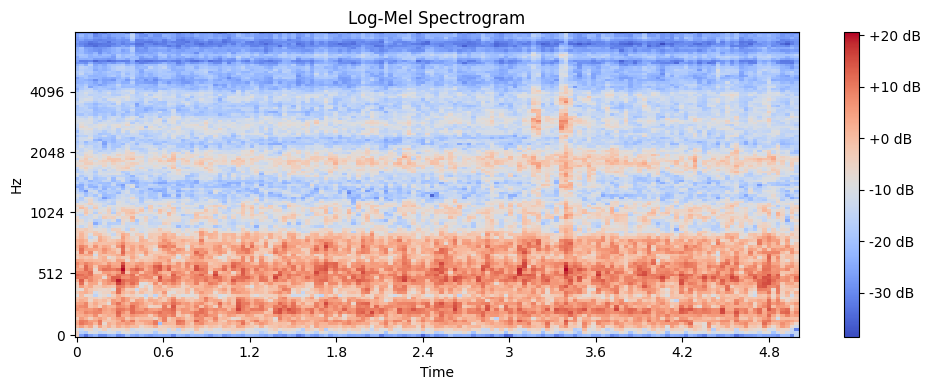

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))

librosa.display.specshow(
    log_mel,
    sr=16000,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

precompute spectrograms

In [ ]:
import os

print(os.path.exists('/content.npy'))
print(os.path.exists('/content_labels.npy'))

True
True


In [ ]:
audio = dataset["train"][0]["audio"].get_all_samples()

waveform = audio.data.squeeze().numpy()

stft = librosa.stft(
    waveform,
    n_fft=1024,
    hop_length=512
)

stft_db = librosa.amplitude_to_db(
    np.abs(stft),
    ref=np.max
)

stft_db = (
    stft_db - stft_db.mean()
) / (
    stft_db.std() + 1e-8
)

print(stft_db.shape)

(513, 157)


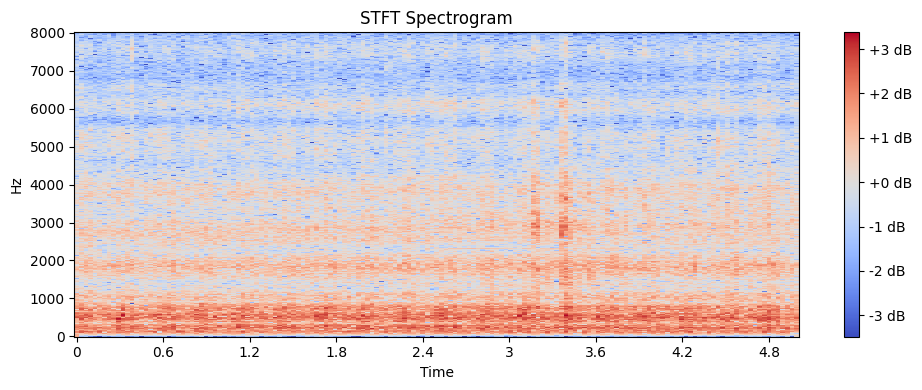

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))

librosa.display.specshow(
    stft_db,
    sr=16000,
    hop_length=512,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("STFT Spectrogram")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

records = []

for i in range(len(dataset["train"])):

    path = dataset["train"][i]["audio"]._hf_encoded["path"]
    filename = path.split("://")[1].split("::")[0]

    cls = filename.split("_")[0]

    if cls == "shipsear":
        continue

    records.append({
        "index": i,
        "label": int(cls)
    })

df = pd.DataFrame(records)

print(df.shape)
print(df.head())

(2223, 2)
   index  label
0      0      0
1      1      0
2      2      0
3      3      0
4      4      0


In [ ]:
X = []
y = []

for i in tqdm(range(len(df))):

    sample_idx = int(df.iloc[i]["index"])
    label = int(df.iloc[i]["label"])

    audio = dataset["train"][sample_idx]["audio"].get_all_samples()

    waveform = audio.data.squeeze().numpy()

    stft = librosa.stft(
        waveform,
        n_fft=1024,
        hop_length=512
    )

    stft_db = librosa.amplitude_to_db(
        np.abs(stft),
        ref=np.max
    )

    stft_db = (
        stft_db - stft_db.mean()
    ) / (
        stft_db.std() + 1e-8
    )

    X.append(stft_db.astype(np.float32))
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(X.shape)

100%|██████████| 2223/2223 [01:49<00:00, 20.37it/s]


(2223, 513, 157)


In [ ]:
X = np.load('/content/drive/MyDrive/DS3500_X_logmel.npy')
y = np.load('/content/drive/MyDrive/DS3500_y.npy')

X = X[:, None, :, :]
X = np.repeat(X, 3, axis=1)

print(X.shape)

(2223, 3, 128, 157)


In [ ]:
X.shape
X.nbytes / 1024**2

170.41552734375

Train/Val/Test Splits from X and y

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)

(1556, 3, 128, 157)


In [ ]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 3, 128, 157])
torch.Size([32])


ResNet18

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

model = resnet18(weights="DEFAULT")

# Change first layer for 1-channel spectrograms
model.conv1 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

from torchvision.models import resnet18
import torch.nn as nn

model = resnet18(weights="DEFAULT")

# Leave conv1 untouched!

model.fc = nn.Linear(
    model.fc.in_features,
    5
)

model = model.to(device)

print(next(model.parameters()).device)

cuda:0


In [ ]:
counts = torch.tensor(
    [369, 301, 843, 486, 224],
    dtype=torch.float32
)

weights = 1.0 / counts
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
num_epochs = 15

best_val_acc = 0

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X, y in train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet18_shipclass.pth"
        )

Epoch 1/15 | Loss: 0.9868 | Val Acc: 0.6877
Epoch 2/15 | Loss: 0.2733 | Val Acc: 0.7838
Epoch 3/15 | Loss: 0.0842 | Val Acc: 0.7928
Epoch 4/15 | Loss: 0.0272 | Val Acc: 0.8078
Epoch 5/15 | Loss: 0.0158 | Val Acc: 0.8018
Epoch 6/15 | Loss: 0.0109 | Val Acc: 0.8288
Epoch 7/15 | Loss: 0.0107 | Val Acc: 0.8138
Epoch 8/15 | Loss: 0.0106 | Val Acc: 0.8288
Epoch 9/15 | Loss: 0.0082 | Val Acc: 0.8198
Epoch 10/15 | Loss: 0.0056 | Val Acc: 0.8318
Epoch 11/15 | Loss: 0.0085 | Val Acc: 0.7958
Epoch 12/15 | Loss: 0.0051 | Val Acc: 0.8168
Epoch 13/15 | Loss: 0.0041 | Val Acc: 0.8348
Epoch 14/15 | Loss: 0.0030 | Val Acc: 0.8438
Epoch 15/15 | Loss: 0.0075 | Val Acc: 0.8048


In [ ]:
model.load_state_dict(
    torch.load("best_resnet18_shipclass.pth")
)

test_acc = evaluate(
    model,
    test_loader
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8532934131736527


In [ ]:
model.load_state_dict(
    torch.load("best_resnet18_shipclass.pth")
)

test_acc = evaluate(model, test_loader)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8532934131736527


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        outputs = model(X)

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)

print(cm)

              precision    recall  f1-score   support

           0       0.89      0.75      0.82        56
           1       0.73      0.73      0.73        45
           2       0.89      0.87      0.88       127
           3       0.80      0.93      0.86        73
           4       0.97      0.97      0.97        33

    accuracy                           0.85       334
   macro avg       0.86      0.85      0.85       334
weighted avg       0.86      0.85      0.85       334

[[ 42   1   4   9   0]
 [  1  33   9   1   1]
 [  4   6 110   7   0]
 [  0   4   1  68   0]
 [  0   1   0   0  32]]
